<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
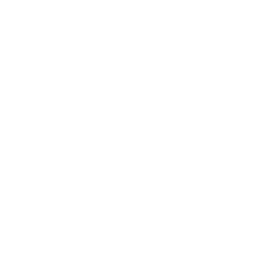
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolação de Inscrições de Trimestral para Mensal</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacêutico / Operações Clínicas &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo executivo

Este exemplo prático converte contagens **trimestrais** de inscrição em ensaio clínico em estimativas **mensais** com PROC EXPAND, para que o planejamento de recursos por centro possa operar em cadência mensal. O ensaio sintético abrange **quatro centros de investigação** em duas regiões (América do Norte e Europa) ao longo de **oito trimestres** (Q1 2024 até Q4 2025), gerando **32 observações trimestrais**. O PROC EXPAND interpola a série de cada centro da frequência trimestral para a mensal, transformando essas 32 linhas trimestrais em **96 linhas mensais**. As contagens de inscritos são interpoladas com `METHOD=JOIN` (linear por partes, que mantém toda estimativa não negativa) e o acumulado corrente é interpolado com `METHOD=SPLINE`. A série mensal interpolada passa exatamente pelos pontos de ancoragem trimestrais originais, portanto a conversão adiciona detalhe intratrimestral sem alterar os números trimestrais que o estudo já reportou.


## Fontes de dados

| Fonte | Descrição | Registros |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Contagens trimestrais de inscrição por centro (4 centros x 8 trimestres) | 32 |
| WORK.SITE_MASTER | Referência do centro: nome, país, região, PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   Gera contagens trimestrais de inscrição por centro.
   4 centros x 8 trimestres (Q1-2024 até Q4-2025) = 32 linhas.
   Uma curva de crescimento (início lento, platô) somada a um
   termo sazonal leve e a pequeno ruído produz um padrão
   realista de inscrição.
   -------------------------------------------------------- */
DADOS work.enrollment_qtr;
    CHAMAR streaminit(42);
    FORMATO quarter_date yyq7.;
    COMPRIMENTO region $20;
    VETOR capacity[4] _temporary_ (12 9 14 8);
    FAZER site_num = 1 ATÉ 4;
        site_id = cat('SITE-', PUT(site_num, z3.));
        region  = ifc(site_num <= 2, 'América do Norte', 'Europa');
        base_rate = capacity[site_num];
        FAZER qtr_seq = 0 ATÉ 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            SAÍDA;
        FIM;
    FIM;
    REMOVER site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
EXECUTAR;

/* Inscrição acumulada corrente dentro de cada centro */
PROCEDIMENTO ORDENAR DADOS=work.enrollment_qtr;
    POR site_id quarter_date;
EXECUTAR;

DADOS work.enrollment_qtr;
    DEFINIR work.enrollment_qtr;
    POR site_id;
    RETER cum_enrolled 0;
    SE first.site_id ENTÃO cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    REMOVER cum_enrolled;
EXECUTAR;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Tabela mestra de referência dos centros (4 centros, 2 regiões)
   -------------------------------------------------------- */
DADOS work.site_master;
    COMPRIMENTO site_id $8 site_name $40 region $20 country $20 pi_name $30;
    VETOR names[4] $40 _temporary_ (
        'Hospital Geral Metropolitano'   'Centro Médico Universitário'
        'Enfermaria Real de Londres'   'Campus Charité de Berlim'
    );
    VETOR countries[4] $20 _temporary_ ('EUA' 'EUA' 'Reino Unido' 'Alemanha');
    FAZER i = 1 ATÉ 4;
        site_id   = cat('SITE-', PUT(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'América do Norte', 'Europa');
        pi_name   = cat('Dr. Pesquisador-', PUT(i, z2.));
        SAÍDA;
    FIM;
    REMOVER i;
EXECUTAR;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Resumo de referência de inscrição trimestral por região
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.enrollment_qtr n sum mean MAX;
    CLASSE region;
    VARIÁVEL enrolled_count cumulative_enrolled;
    RÓTULO region="Região" enrolled_count="Inscritos no Trimestre" cumulative_enrolled="Inscritos Acumulados";
    SAÍDA out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.qtr_baseline noobs RÓTULO;
    RÓTULO region="Região" total_enrolled="Total de Inscritos" avg_per_quarter="Média por Trimestre" max_cumulative="Máximo Acumulado";
    TÍTULO 'Linha de Base de Inscrição Trimestral por Região';
EXECUTAR;


                                                  The MEANS Procedure

                               Analysis Variable : enrolled_count Inscritos no Trimestre

        Região                     N Obs            Sum           Mean        Maximum
        -----------------------------------------------------------------------------
        América do Norte              16    115.0000000      7.1875000     10.0000000
        Europa                        16    120.0000000      7.5000000     13.0000000
        -----------------------------------------------------------------------------

                              Analysis Variable : cumulative_enrolled Inscritos Acumulados

        Região                     N Obs            Sum           Mean        Maximum
        -----------------------------------------------------------------------------
        América do Norte              16    474.0000000     29.6250000     63.0000000
        Europa                        16    493.0000000   


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


A linha de base confirma um desenho balanceado: cada região contribui com **16 observações trimestrais**. A América do Norte inscreve um total de **115 sujeitos** (média **7.19** por centro-trimestre) e a Europa **120** (média **7.50**). A maior contagem acumulada alcançada ao longo dos oito trimestres é de **81** sujeitos (o SITE-003 da Europa) contra **63** na América do Norte.


---

                                    Linha de Base de Inscrição Trimestral por Região                                    




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


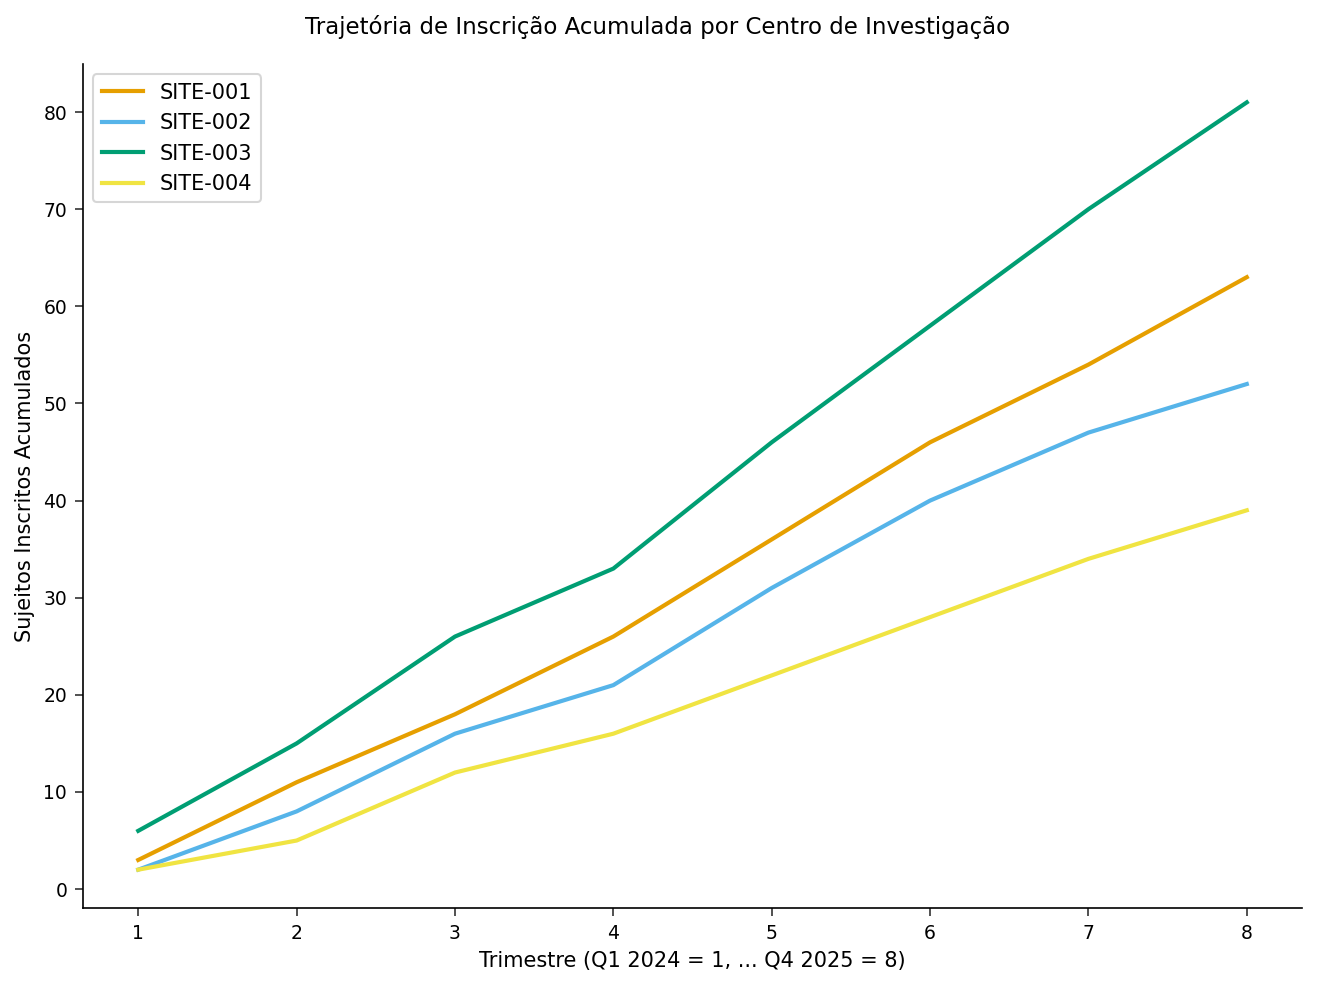

In [4]:
/* --------------------------------------------------------
   Trajetória trimestral acumulada de inscrição por centro.
   Plotada contra um índice de trimestre (1..8) para um eixo
   limpo.
   -------------------------------------------------------- */
DADOS work.traj;
    DEFINIR work.enrollment_qtr;
    POR site_id;
    RETER quarter_index 0;
    SE first.site_id ENTÃO quarter_index = 0;
    quarter_index + 1;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS RÓTULO='Trimestre (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 ATÉ 8 POR 1);
    YAXIS RÓTULO='Sujeitos Inscritos Acumulados';
    TÍTULO 'Trajetória de Inscrição Acumulada por Centro de Investigação';
EXECUTAR;


---

In [5]:
/* --------------------------------------------------------
   O PROC EXPAND exige que a variável ID esteja ordenada dentro
   de cada grupo BY, portanto ordene por centro e depois
   trimestre antes de converter.
   -------------------------------------------------------- */
PROCEDIMENTO ORDENAR DADOS=work.enrollment_qtr;
    POR site_id quarter_date;
EXECUTAR;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Converte a inscrição trimestral em estimativas mensais.

   FROM=QTR / TO=MONTH na instrução PROC definem as frequências
   de entrada e saída; o PROC EXPAND interpola cada grupo BY
   (centro) de forma independente ao longo da data ID.

   enrolled_count      -> METHOD=JOIN   (linear por partes; o
                          valor de fluxo permanece não negativo
                          entre âncoras)
   cumulative_enrolled -> METHOD=SPLINE (curva monótona suave)
   -------------------------------------------------------- */
PROCEDIMENTO expand DADOS=work.enrollment_qtr
            out=work.enrollment_monthly
            DE_TABELA=qtr ATÉ=month;
    POR site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=FIM     METHOD=SPLINE;
EXECUTAR;


                                    Linha de Base de Inscrição Trimestral por Região                                    




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                    Linha de Base de Inscrição Trimestral por Região                                    




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


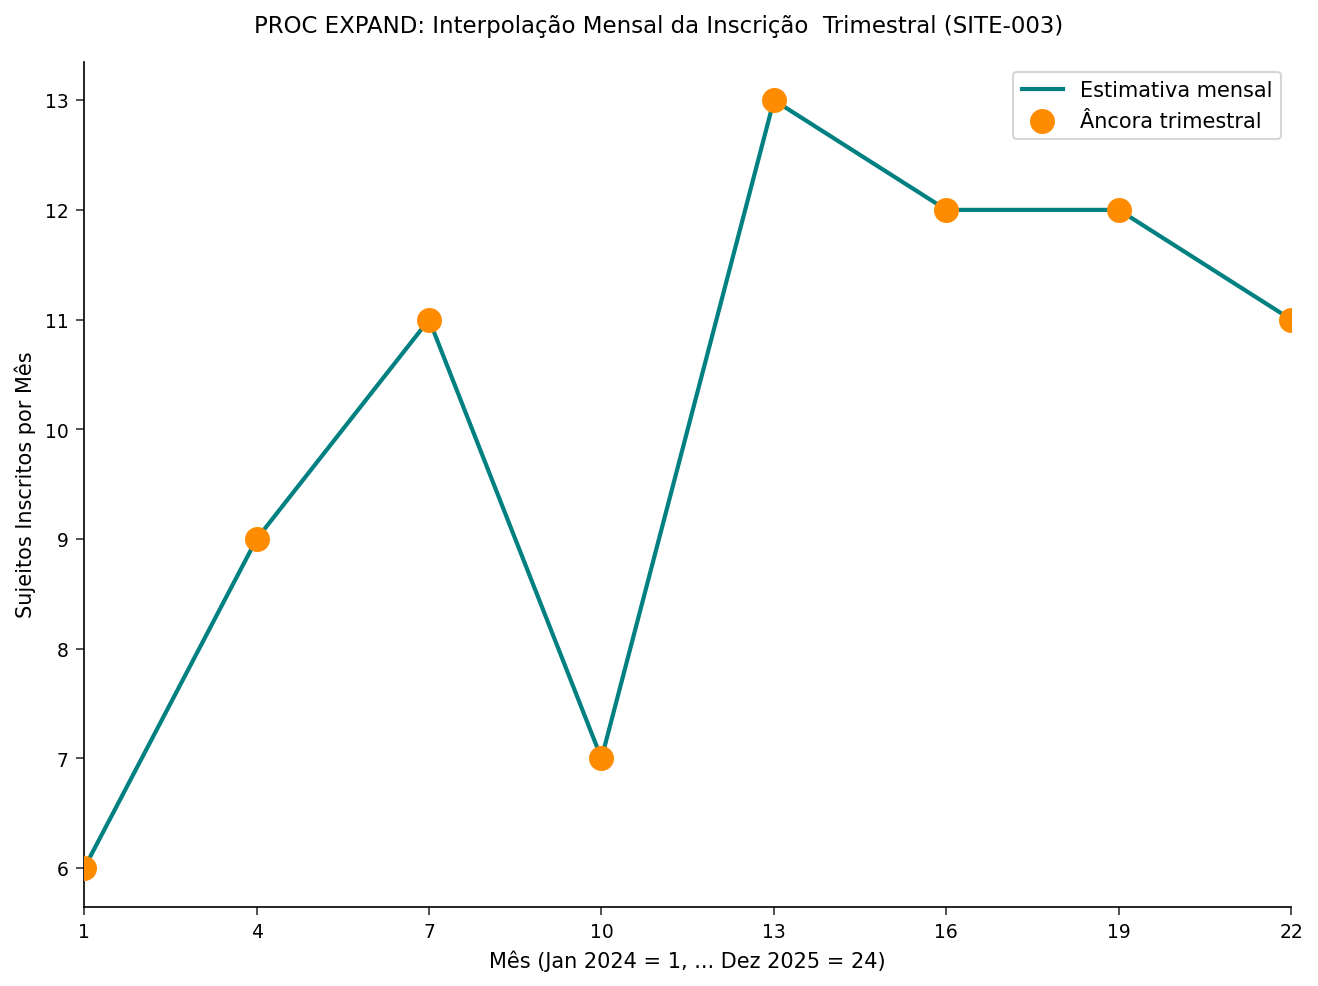

In [7]:
/* --------------------------------------------------------
   A variável ID agora carrega datas mensais. Reformate-a e
   adicione um índice de mês dentro do centro (1..24) para
   plotar.
   -------------------------------------------------------- */
DADOS work.enrollment_monthly;
    DEFINIR work.enrollment_monthly;
    POR site_id;
    FORMATO month_date monyy7.;
    month_date = quarter_date;
    RETER month_index 0;
    SE first.site_id ENTÃO month_index = 0;
    month_index + 1;
    /* marca os meses de ancoragem trimestral (1, 4, 7, ...) */
    SE mod(month_index - 1, 3) = 0 ENTÃO anchor = enrolled_count;
    SENÃO anchor = .;
EXECUTAR;

/* Mostra a conversão para um centro: a linha mensal interpolada
   passa pelos pontos de ancoragem trimestrais originais. */
PROCEDIMENTO SGPLOT DADOS=work.enrollment_monthly;
    ONDE site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Estimativa mensal';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Âncora trimestral';
    XAXIS RÓTULO='Mês (Jan 2024 = 1, ... Dez 2025 = 24)'
        integer VALUES=(1 ATÉ 24 POR 3);
    YAXIS RÓTULO='Sujeitos Inscritos por Mês';
    TÍTULO 'PROC EXPAND: Interpolação Mensal da Inscrição '
        'Trimestral (SITE-003)';
EXECUTAR;


In [8]:
/* --------------------------------------------------------
   Junta as estimativas mensais aos metadados do centro, depois
   resume a inscrição mensal por região.
   -------------------------------------------------------- */
PROCEDIMENTO SQL;
    CRIAR TABELA work.enrollment_monthly_region AS
    SELECIONAR e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    DE_TABELA work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER POR s.region, e.site_id, e.month_date;
QUIT;

PROCEDIMENTO MÉDIAS DADOS=work.enrollment_monthly_region n sum mean;
    CLASSE region;
    VARIÁVEL monthly_estimate cumulative_estimate;
    RÓTULO region="Região" monthly_estimate="Estimativa Mensal" cumulative_estimate="Estimativa Acumulada";
    SAÍDA out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.region_monthly_summary noobs RÓTULO;
    RÓTULO region="Região" total_monthly_enrolled="Total Mensal Inscrito" avg_monthly_rate="Taxa Média Mensal";
    TÍTULO 'Estimativas Mensais por Região';
EXECUTAR;


                                    Linha de Base de Inscrição Trimestral por Região                                    

                                    Linha de Base de Inscrição Trimestral por Região                                    

                                                  The MEANS Procedure

                                 Analysis Variable : monthly_estimate Estimativa Mensal

        Região                     N Obs            Sum           Mean
        --------------------------------------------------------------
        América do Norte              44    326.0000000      7.4090909
        Europa                        44    336.0000000      7.6363636
        --------------------------------------------------------------

                              Analysis Variable : cumulative_estimate Estimativa Acumulada

        Região                     N Obs            Sum           Mean
        --------------------------------------------------------------
      


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interpretação

O PROC EXPAND converteu os **32 registros trimestrais** (4 centros x 8 trimestres) em **96 registros mensais** usando conversão de frequência ao longo da data de cada centro. A série mensal interpolada passa pelos valores de ancoragem trimestrais originais exatamente, como mostra o gráfico do SITE-003: os pontos laranja são as oito contagens trimestrais reportadas e a linha azul-petróleo é a estimativa mensal desagregada que os conecta.

Em base mensal, as duas regiões acompanham-se de perto. A Europa tem média de **7.64** sujeitos inscritos por centro-mês e a América do Norte **7.41**, com totais mensais regionais de **336** e **326** sujeitos ao longo do horizonte interpolado. Como `METHOD=JOIN` não extrapola além da última ancoragem trimestral, os meses finais de trimestre parcial não carregam estimativa e são excluídos das médias mensais, o que é a escolha conservadora para o planejamento prospectivo.

Essas projeções mensais permitem que as operações clínicas passem de uma cadência de planejamento trimestral para mensal -- dimensionando remessas de suprimento de medicamentos, agendando visitas de monitoramento e reportando a inscrição ao Comitê de Monitoramento de Segurança de Dados (Data Safety Monitoring Board) -- sem reformular nenhum dos números trimestrais que o estudo já consolidou.


---

In [9]:
/* --------------------------------------------------------
   Exporta as projeções mensais de inscrição para ferramentas
   de planejamento posteriores.
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
EXECUTAR;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>